# Sudoku Belief Propagation Experiments

Important: zeros in the puzzle mean **empty cells to fill**.
BP estimates beliefs over digits 1..9 for each empty cell.

This notebook runs the 100-puzzle benchmark and visualizes solve/convergence stats.
            


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if not (PROJECT_ROOT / 'datasets').exists():
    PROJECT_ROOT = Path('/mnt/D/mva_P2/GRM/belief_propagation')

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datasets.sudoku_loader import load_sudoku_dataset
from experiments.sudoku_bp_solver import run_experiment
            


In [2]:
# Preview puzzles: 0 means an unknown cell.
puzzles = load_sudoku_dataset(n_samples=3)
for idx, puzzle in enumerate(puzzles):
    print(f'Puzzle {idx} (0 = empty):')
    print(puzzle)
    print('-' * 40)
            


Puzzle 0 (0 = empty):
[[4 6 7 1 0 0 8 0 5]
 [9 1 2 8 3 5 6 0 7]
 [0 8 5 6 4 7 1 9 2]
 [2 9 6 3 5 1 4 7 0]
 [7 0 8 9 2 0 3 5 1]
 [5 3 1 4 0 8 9 2 6]
 [0 7 3 0 6 4 5 1 0]
 [6 2 4 5 1 9 7 8 3]
 [1 5 9 7 8 3 0 6 4]]
----------------------------------------
Puzzle 1 (0 = empty):
[[0 0 6 5 1 3 0 0 0]
 [0 0 1 9 0 4 0 3 6]
 [3 0 2 0 6 0 0 1 0]
 [0 6 3 0 0 0 0 0 0]
 [4 8 0 0 7 0 3 9 0]
 [0 0 9 0 3 0 0 6 5]
 [0 0 0 0 0 7 0 5 0]
 [0 0 0 6 4 0 0 0 0]
 [6 5 7 0 0 1 9 2 0]]
----------------------------------------
Puzzle 2 (0 = empty):
[[1 0 0 5 6 0 9 3 0]
 [0 3 9 0 0 0 0 0 6]
 [0 5 0 0 0 0 0 0 0]
 [0 1 0 6 4 8 5 7 9]
 [4 0 0 7 9 5 0 1 2]
 [0 0 0 1 2 3 8 6 4]
 [5 0 0 2 0 0 1 4 8]
 [3 0 0 4 0 1 6 0 0]
 [8 0 0 9 5 6 0 0 3]]
----------------------------------------


In [3]:
# Run benchmark on 100 puzzles.
import argparse

RESULTS_DIR = PROJECT_ROOT / 'results' / 'sudoku'
args = argparse.Namespace(
    n_samples=100,
    max_iters=150,
    tol=1e-3,
    damping=0.5,
    seed=0,
    results_dir=str(RESULTS_DIR),
)
summary = run_experiment(args)
summary
            


[1/100] Solved=True CluesOK=True Converged=True Iter=14 Runtime=1.035s
[2/100] Solved=True CluesOK=True Converged=True Iter=33 Runtime=2.491s
[3/100] Solved=True CluesOK=True Converged=True Iter=26 Runtime=1.743s
[4/100] Solved=True CluesOK=True Converged=True Iter=32 Runtime=2.274s
[5/100] Solved=True CluesOK=True Converged=True Iter=35 Runtime=2.405s
[6/100] Solved=True CluesOK=True Converged=True Iter=22 Runtime=1.498s
[7/100] Solved=True CluesOK=True Converged=True Iter=22 Runtime=1.484s
[8/100] Solved=True CluesOK=True Converged=True Iter=38 Runtime=2.694s
[9/100] Solved=True CluesOK=True Converged=True Iter=35 Runtime=2.458s
[10/100] Solved=True CluesOK=True Converged=True Iter=24 Runtime=1.525s
[11/100] Solved=True CluesOK=True Converged=True Iter=20 Runtime=1.680s
[12/100] Solved=True CluesOK=True Converged=True Iter=16 Runtime=1.148s
[13/100] Solved=True CluesOK=True Converged=True Iter=30 Runtime=2.246s
[14/100] Solved=True CluesOK=True Converged=True Iter=36 Runtime=2.737s
[

{'num_puzzles': 100,
 'solve_rate': 0.97,
 'solve_rate_std': 0.17058722109231983,
 'clue_consistency_rate': 1.0,
 'convergence_rate': 0.98,
 'mean_iterations': 30.13,
 'std_iterations': 18.678144982840237,
 'mean_runtime_sec': 2.3566208988497963,
 'std_runtime_sec': 1.453331713400377,
 'config': {'n_samples': 100,
  'max_iters': 150,
  'tol': 0.001,
  'damping': 0.5,
  'seed': 0}}

In [5]:
summary_path = RESULTS_DIR / 'summary.json'
with summary_path.open() as f:
    summary = json.load(f)

print(json.dumps(summary, indent=2))
print('Interpretation:')
print(f"- Solve rate: {summary['solve_rate']:.3f}")
print(f"- Convergence rate: {summary['convergence_rate']:.3f}")
print(f"- Mean iterations: {summary['mean_iterations']:.2f}")
print(f"- Mean runtime (s): {summary['mean_runtime_sec']:.4f}")
            


{
  "num_puzzles": 100,
  "solve_rate": 0.97,
  "solve_rate_std": 0.17058722109231983,
  "clue_consistency_rate": 1.0,
  "convergence_rate": 0.98,
  "mean_iterations": 30.13,
  "std_iterations": 18.678144982840237,
  "mean_runtime_sec": 2.3566208988497963,
  "std_runtime_sec": 1.453331713400377,
  "config": {
    "n_samples": 100,
    "max_iters": 150,
    "tol": 0.001,
    "damping": 0.5,
    "seed": 0
  }
}
Interpretation:
- Solve rate: 0.970
- Convergence rate: 0.980
- Mean iterations: 30.13
- Mean runtime (s): 2.3566


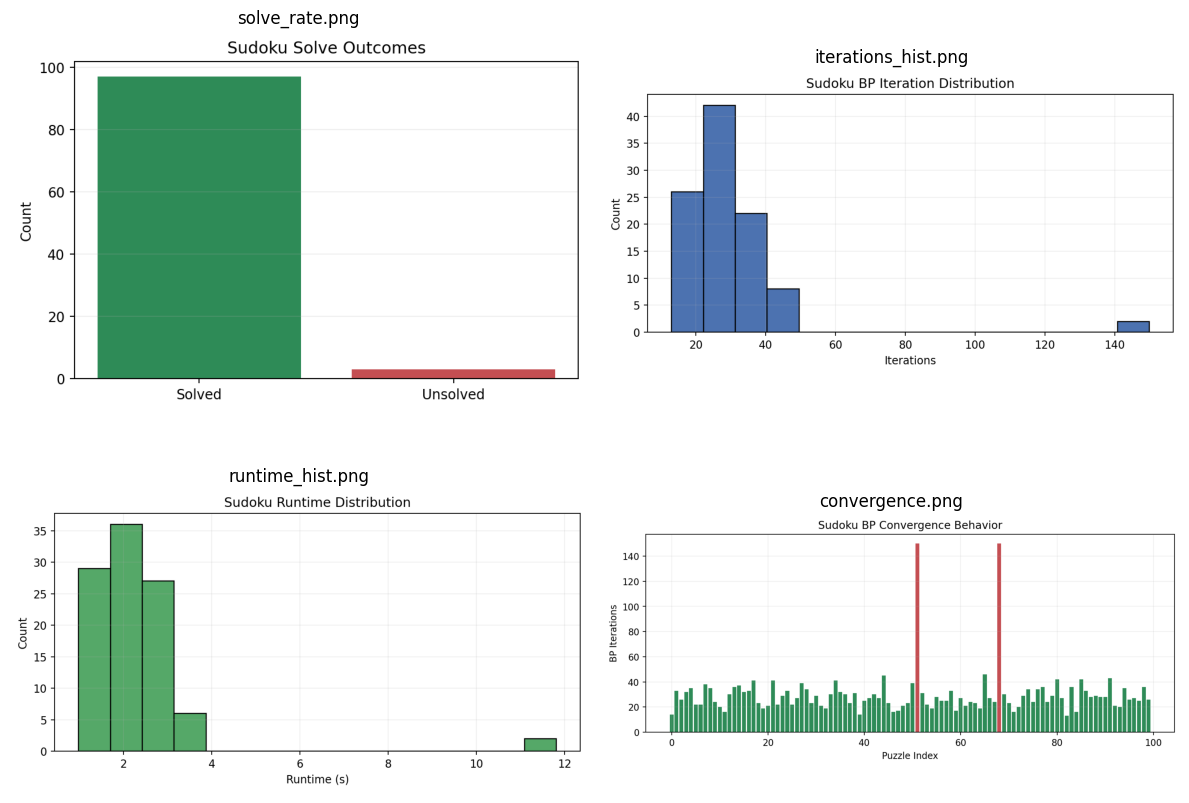

In [6]:
plot_paths = [
    RESULTS_DIR / 'plots' / 'solve_rate.png',
    RESULTS_DIR / 'plots' / 'iterations_hist.png',
    RESULTS_DIR / 'plots' / 'runtime_hist.png',
    RESULTS_DIR / 'plots' / 'convergence.png',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, path in zip(axes.ravel(), plot_paths):
    if path.exists():
        ax.imshow(plt.imread(path))
        ax.set_title(path.name)
    else:
        ax.text(0.5, 0.5, f'Missing: {path.name}', ha='center', va='center')
    ax.axis('off')
plt.tight_layout()
            


## Tree-Reweighted Belief Propagation (TRW)

This section runs TRW and compares BP vs TRW on:
- solve rate
- convergence behavior
- runtime
            


In [ ]:
import argparse
from experiments.sudoku_bp_solver_trw import run_experiment as run_trw_experiment

TRW_ARGS = argparse.Namespace(
    n_samples=100,
    max_iters=150,
    tol=1e-3,
    damping=0.5,
    seed=0,
    results_dir=str(RESULTS_DIR),
)
trw_summary = run_trw_experiment(TRW_ARGS)
trw_summary
            


In [ ]:
import csv

bp_csv = RESULTS_DIR / 'metrics.csv'
trw_csv = RESULTS_DIR / 'sudoku_trw_metrics.csv'


def load_metrics(path):
    rows = []
    with path.open() as f:
        for row in csv.DictReader(f):
            rows.append({k: float(v) for k, v in row.items()})
    return rows

bp_rows = load_metrics(bp_csv)
trw_rows = load_metrics(trw_csv)

bp_solve = np.array([r['solved'] for r in bp_rows])
trw_solve = np.array([r['solved'] for r in trw_rows])
bp_runtime = np.array([r['runtime_sec'] for r in bp_rows])
trw_runtime = np.array([r['runtime_sec'] for r in trw_rows])

bp_iter = np.array([r['iterations'] for r in bp_rows])
trw_iter = np.array([r['iterations'] for r in trw_rows])
bp_conv = np.array([r['converged'] for r in bp_rows])
trw_conv = np.array([r['converged'] for r in trw_rows])

max_iter = int(max(bp_iter.max(), trw_iter.max()))
ts = np.arange(1, max_iter + 1)
bp_curve = [np.mean((bp_conv > 0.5) & (bp_iter <= t)) for t in ts]
trw_curve = [np.mean((trw_conv > 0.5) & (trw_iter <= t)) for t in ts]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['BP', 'TRW'], [bp_solve.mean(), trw_solve.mean()], color=['#4C72B0', '#6A3D9A'])
axes[0].set_title('Solve Rate')
axes[0].set_ylim(0, 1)

axes[1].bar(['BP', 'TRW'], [bp_runtime.mean(), trw_runtime.mean()], color=['#55A868', '#C44E52'])
axes[1].set_title('Mean Runtime (s)')

axes[2].plot(ts, bp_curve, label='BP', color='#4C72B0')
axes[2].plot(ts, trw_curve, label='TRW', color='#6A3D9A')
axes[2].set_title('Convergence Curve')
axes[2].set_xlabel('Iteration threshold')
axes[2].set_ylabel('Fraction converged')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.2)
axes[2].legend()

plt.tight_layout()

print(f'BP solve_rate={bp_solve.mean():.4f}, TRW solve_rate={trw_solve.mean():.4f}')
print(f'BP mean runtime={bp_runtime.mean():.4f}s, TRW mean runtime={trw_runtime.mean():.4f}s')
            
